In [455]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import signal
import ast

# Load all data
all_eeg = []
all_aux = []
all_mark = []
all_inds = []
for run in range(1, 9):
    eeg = np.load(f"person-1eeg_2-per-class_run-{run}.npy")
    aux = np.load(f"person-1aux_2-per-class_run-{run}.npy")
    mark = np.load(f"person-1markers_2-per-class_run-{run}.npy")
    with open(f"person-1tar_inds_2-per-class_run-{run}.txt", "r") as f:
        first_line = f.readline()
    target_inds = ast.literal_eval(first_line)
    all_eeg.append(eeg)
    all_aux.append(aux)
    all_mark.append(mark)
    all_inds.append(target_inds)
    
    # print('eeg', eeg.shape)
    # print('aux', aux.shape)
    # print('markers', mark.shape)
    # print('indices', target_inds)

In [456]:
all_runs_trigger = []
all_runs_mark = []

for run in range(8):
    # Calculate stim indices from the trigger
    threshold = 78
    trigger = all_aux[run][1, :]
    temp_trials = np.where(trigger > threshold)[0]
    all_trials_trigger = [temp_trials[0]]
    
    # Need to filter out the false stimulation triggers
    for trial in temp_trials[1:]:
        if trial - all_trials_trigger[-1] >= 10:
            all_trials_trigger.append(trial)
    all_trials_trigger = np.array(all_trials_trigger)
    all_runs_trigger.append(all_trials_trigger)
    
    # Calculate stim indices from the markers
    all_trials_mark = np.where(mark > 0)[0]
    all_runs_mark.append(all_runs_mark)
    
    # print(all_trials_trigger.shape)
    # print(all_trials_trigger)
    # print(all_trials_mark.shape)
    # print(all_trials_mark)

In [457]:
# Calculate sampling rate
trial_diff = all_runs_trigger[0][1] - all_runs_trigger[0][0]
time_diff = 0.85 # 0.3s for trial, 0.5s for in between trial, Average 0.5s from jitter

fs = sample_diff / time_diff
dt = 1000 / fs

print(fs)
print(dt)

# Define ERP-related variables
channels = np.array(['O1', 'O2', 'T5', 'P3', 'Pz', 'P4', 'T6', 'REF'])
epoch_start = 0    # ms
epoch_end = 700    # ms
baseline_start = 0 # ms
baseline_end = 200 # ms
erp_start = 200    # ms
erp_end = 400      # ms
hp = 0.1           # Hz; our low cut for our bandpass
lp = 30            # Hz; our high cut for our bandpass
baseline_duration = 0.2
baseline_duration_samples = int(baseline_duration * fs)
num_taps = 100
b = signal.firwin(numtaps=num_taps, cutoff=[hp, lp], pass_zero='bandpass', fs=fs)
a = 1

244.7058823529412
4.086538461538462


In [458]:
# Filter and clean the eeg data
ref_ind = np.where(channels == 'REF')[0][0]
eeg_runs = []

for run in range(8):
    eeg_trials = [[],[],[],[],[],[],[],[]]
    
    for i, c in enumerate(channels):
        referenced_eeg = all_eeg[run] - all_eeg[run][ref_ind] # Subtract reference from all channels
        filtered_eeg = signal.filtfilt(b, a, referenced_eeg[i])
        # filtered_eeg = signal.filtfilt(b, a, all_eeg[run][i])
        
        for j, trial in enumerate(all_runs_trigger[run]):
            if 1 < j < 96: # Need to discard trials at the end because there aren't enough samples
                trial_start = int(trial - baseline_duration_samples)
                trial_duration = int(int(dt * fs) + baseline_duration_samples)
                trial_eeg = np.copy(filtered_eeg[trial_start:trial_start+trial_duration])
                baseline_average = np.mean(trial_eeg[:baseline_duration_samples])
                trial_eeg -= baseline_average        
                eeg_trials[i].append(trial_eeg)
    eeg_runs.append(eeg_trials)

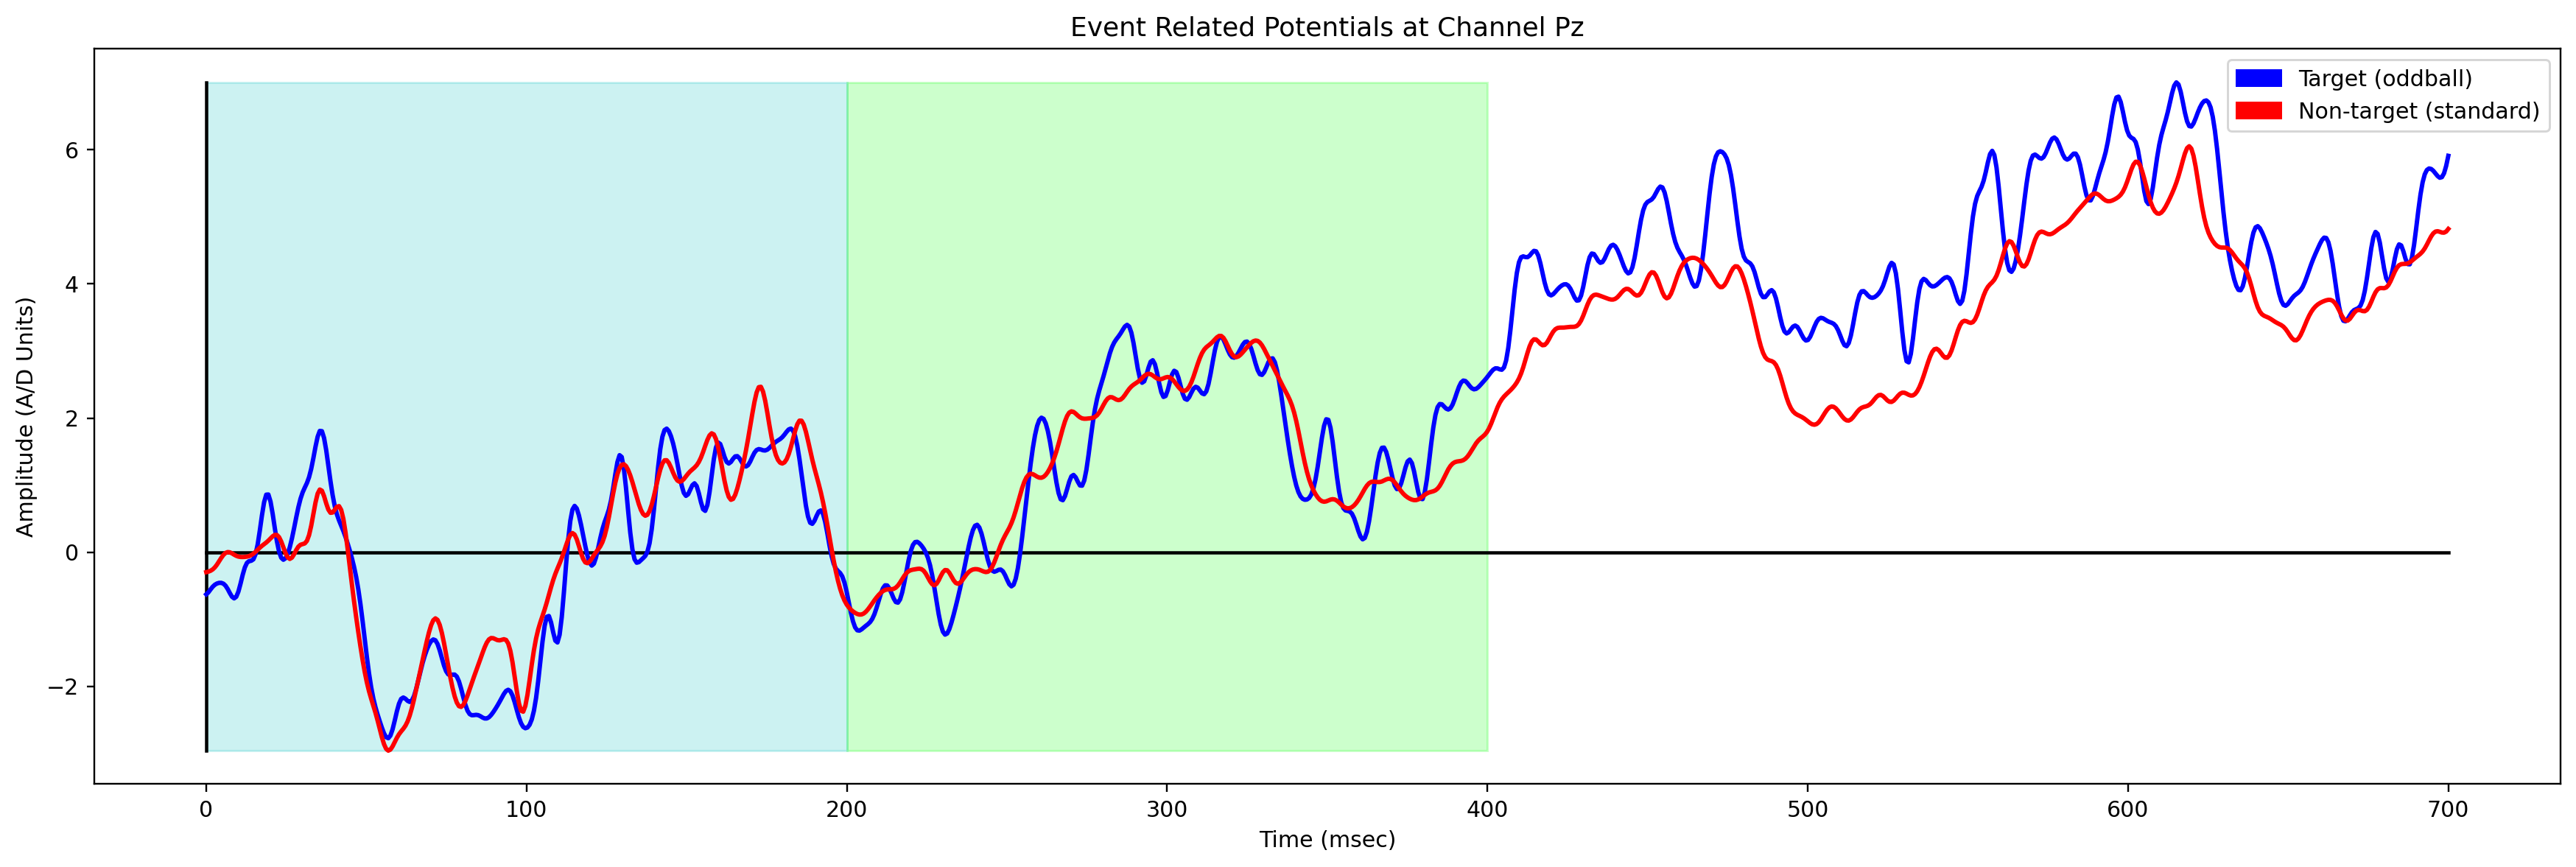

In [459]:
# Plot the graph
ch = 'Pz'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

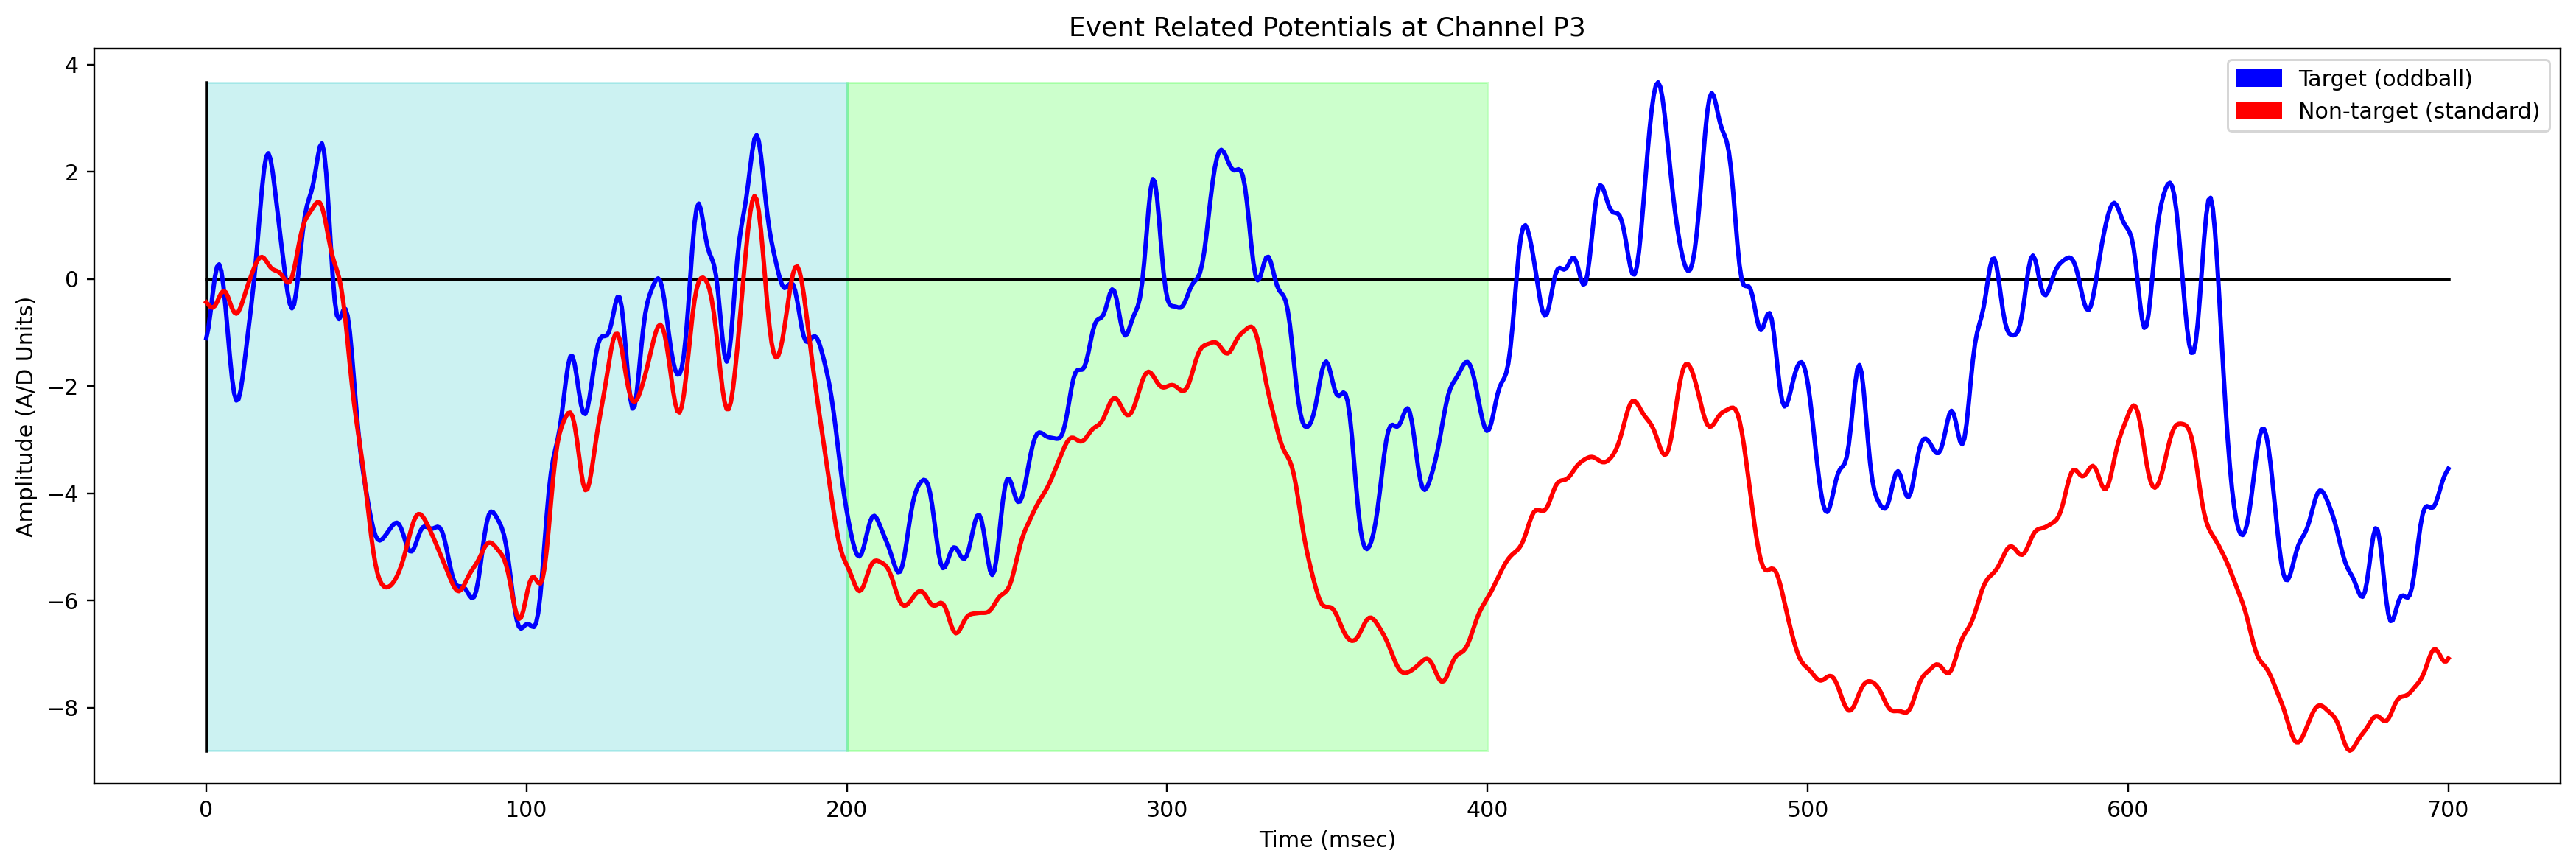

In [460]:
# Plot the graph
ch = 'P3'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

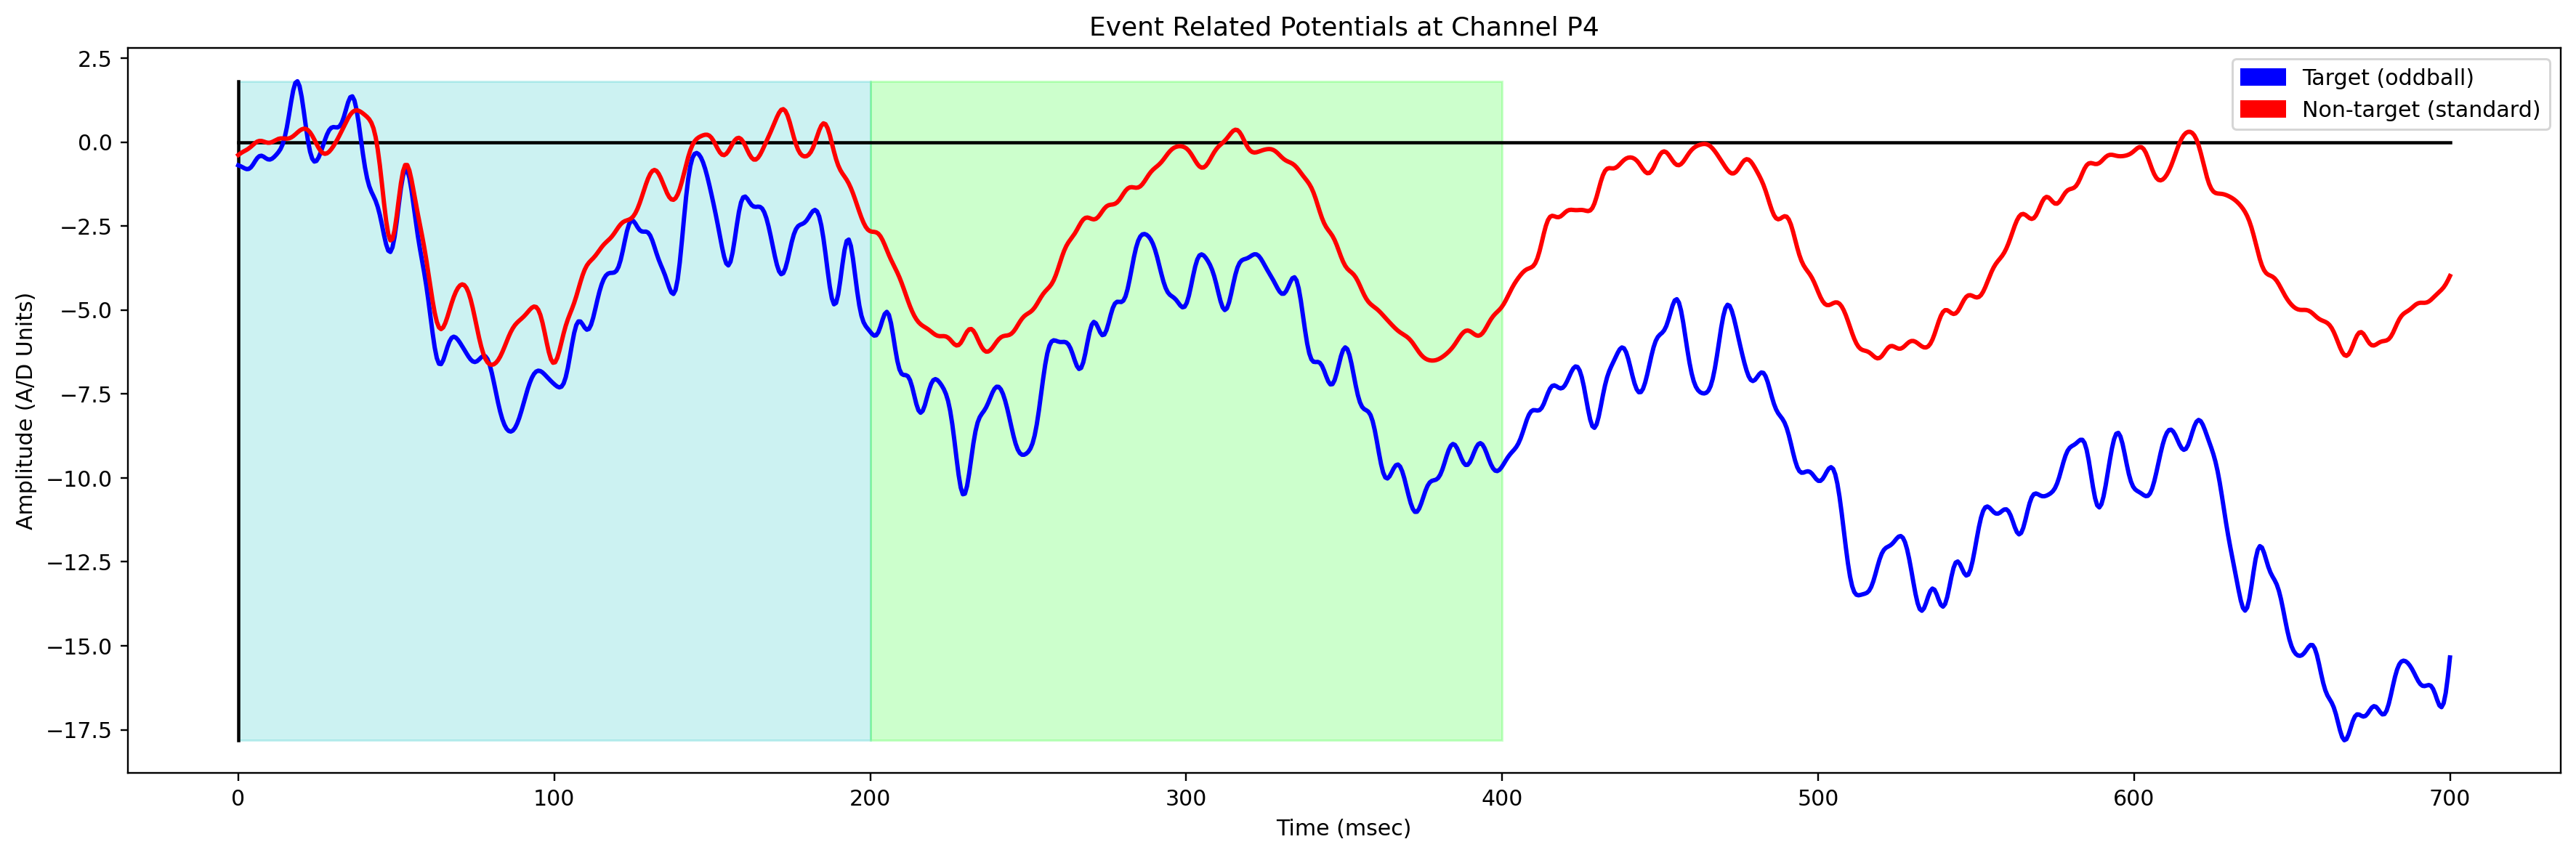

In [461]:
# Plot the graph
ch = 'P4'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

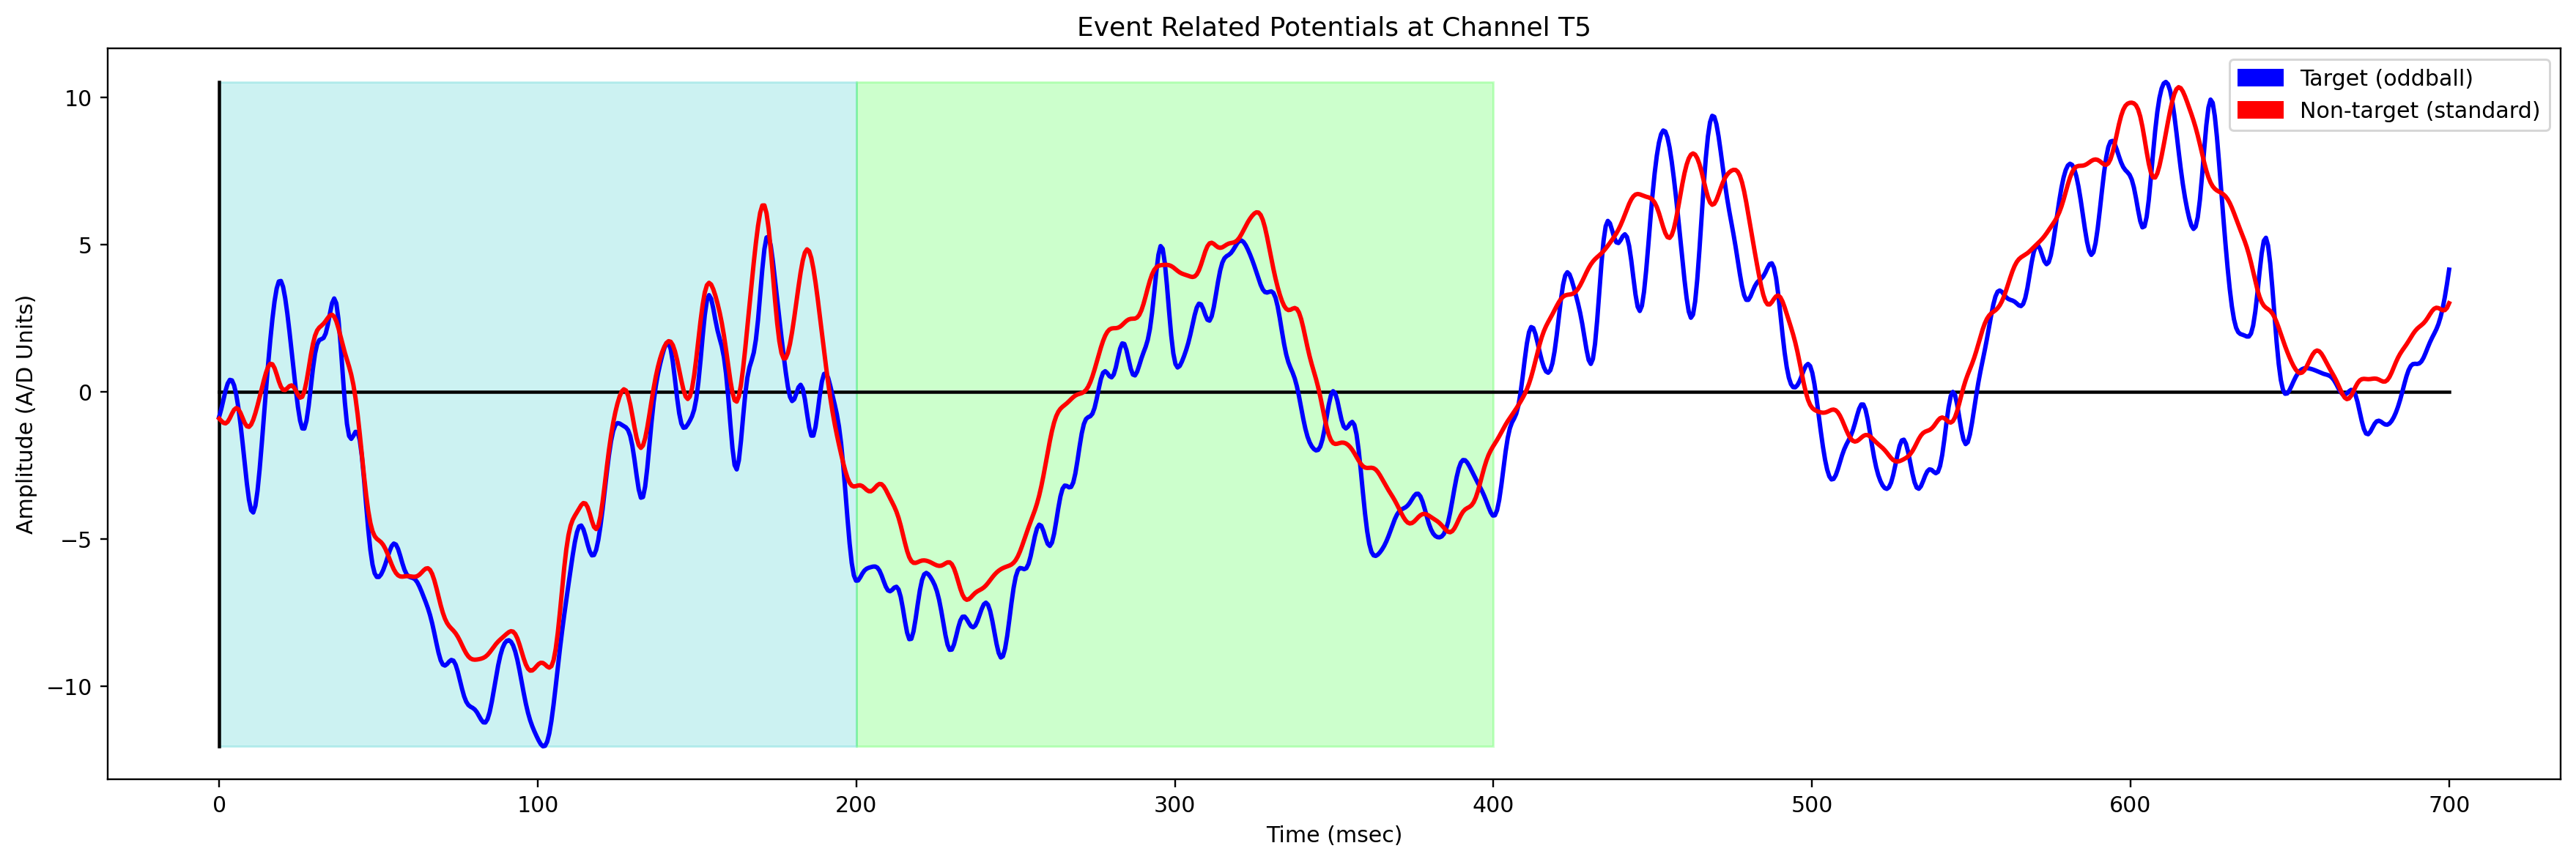

In [462]:
# Plot the graph
ch = 'T5'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

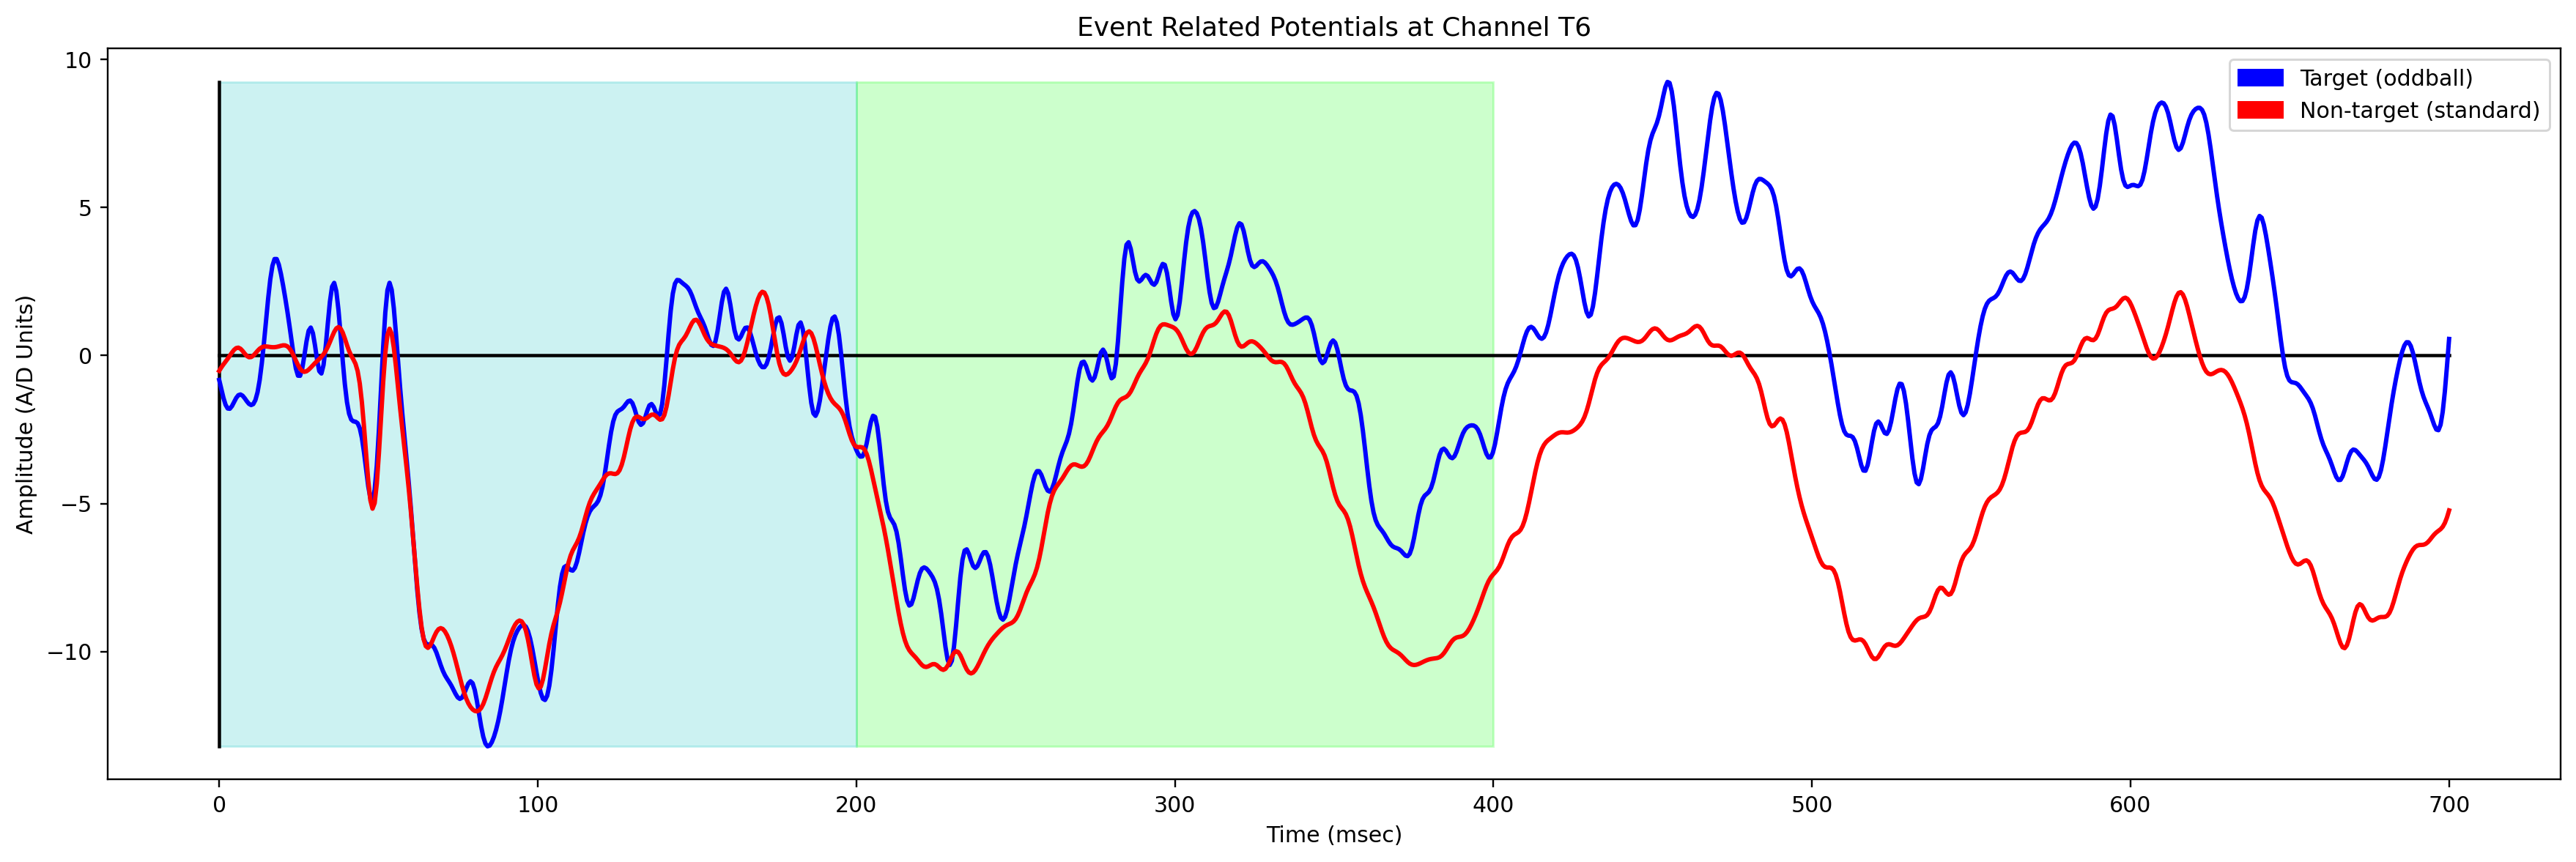

In [463]:
# Plot the graph
ch = 'T6'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

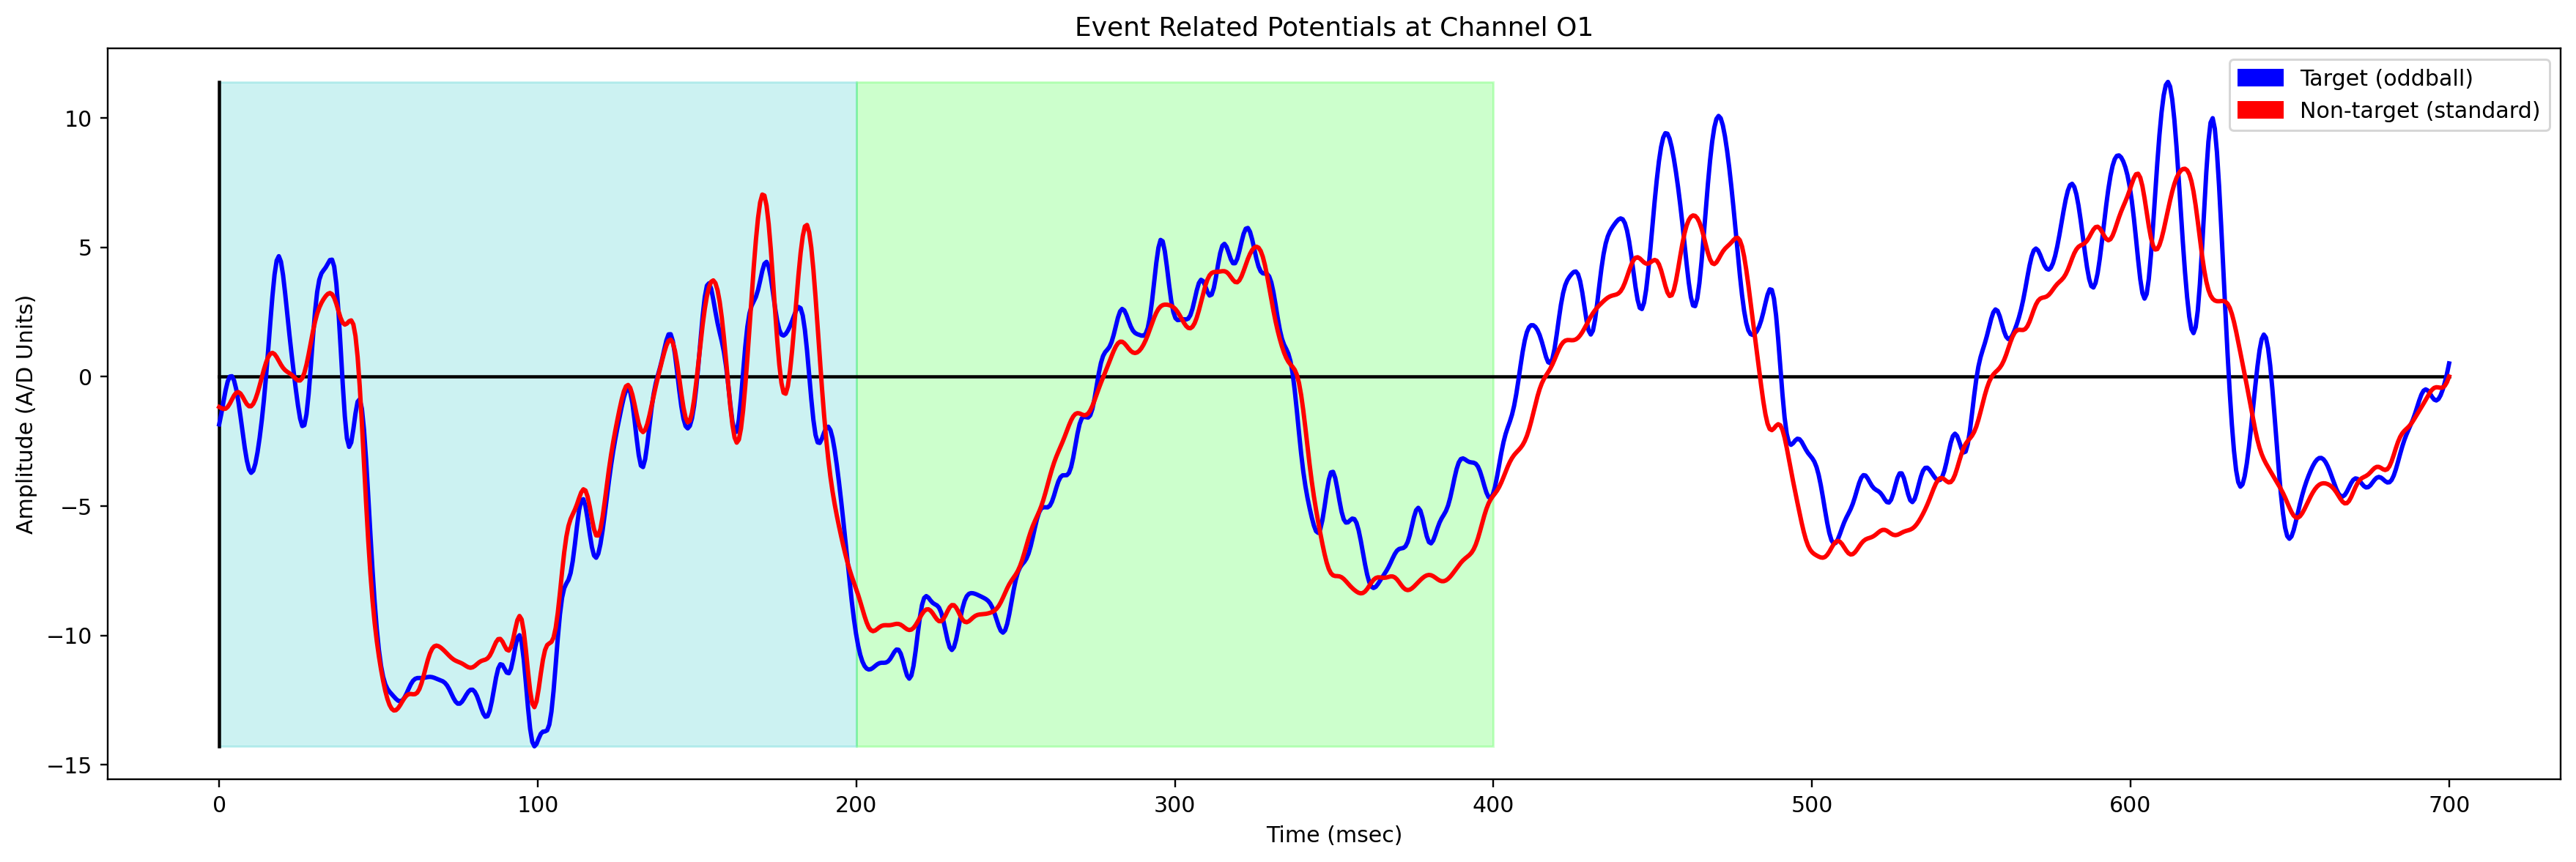

In [464]:
# Plot the graph
ch = 'O1'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

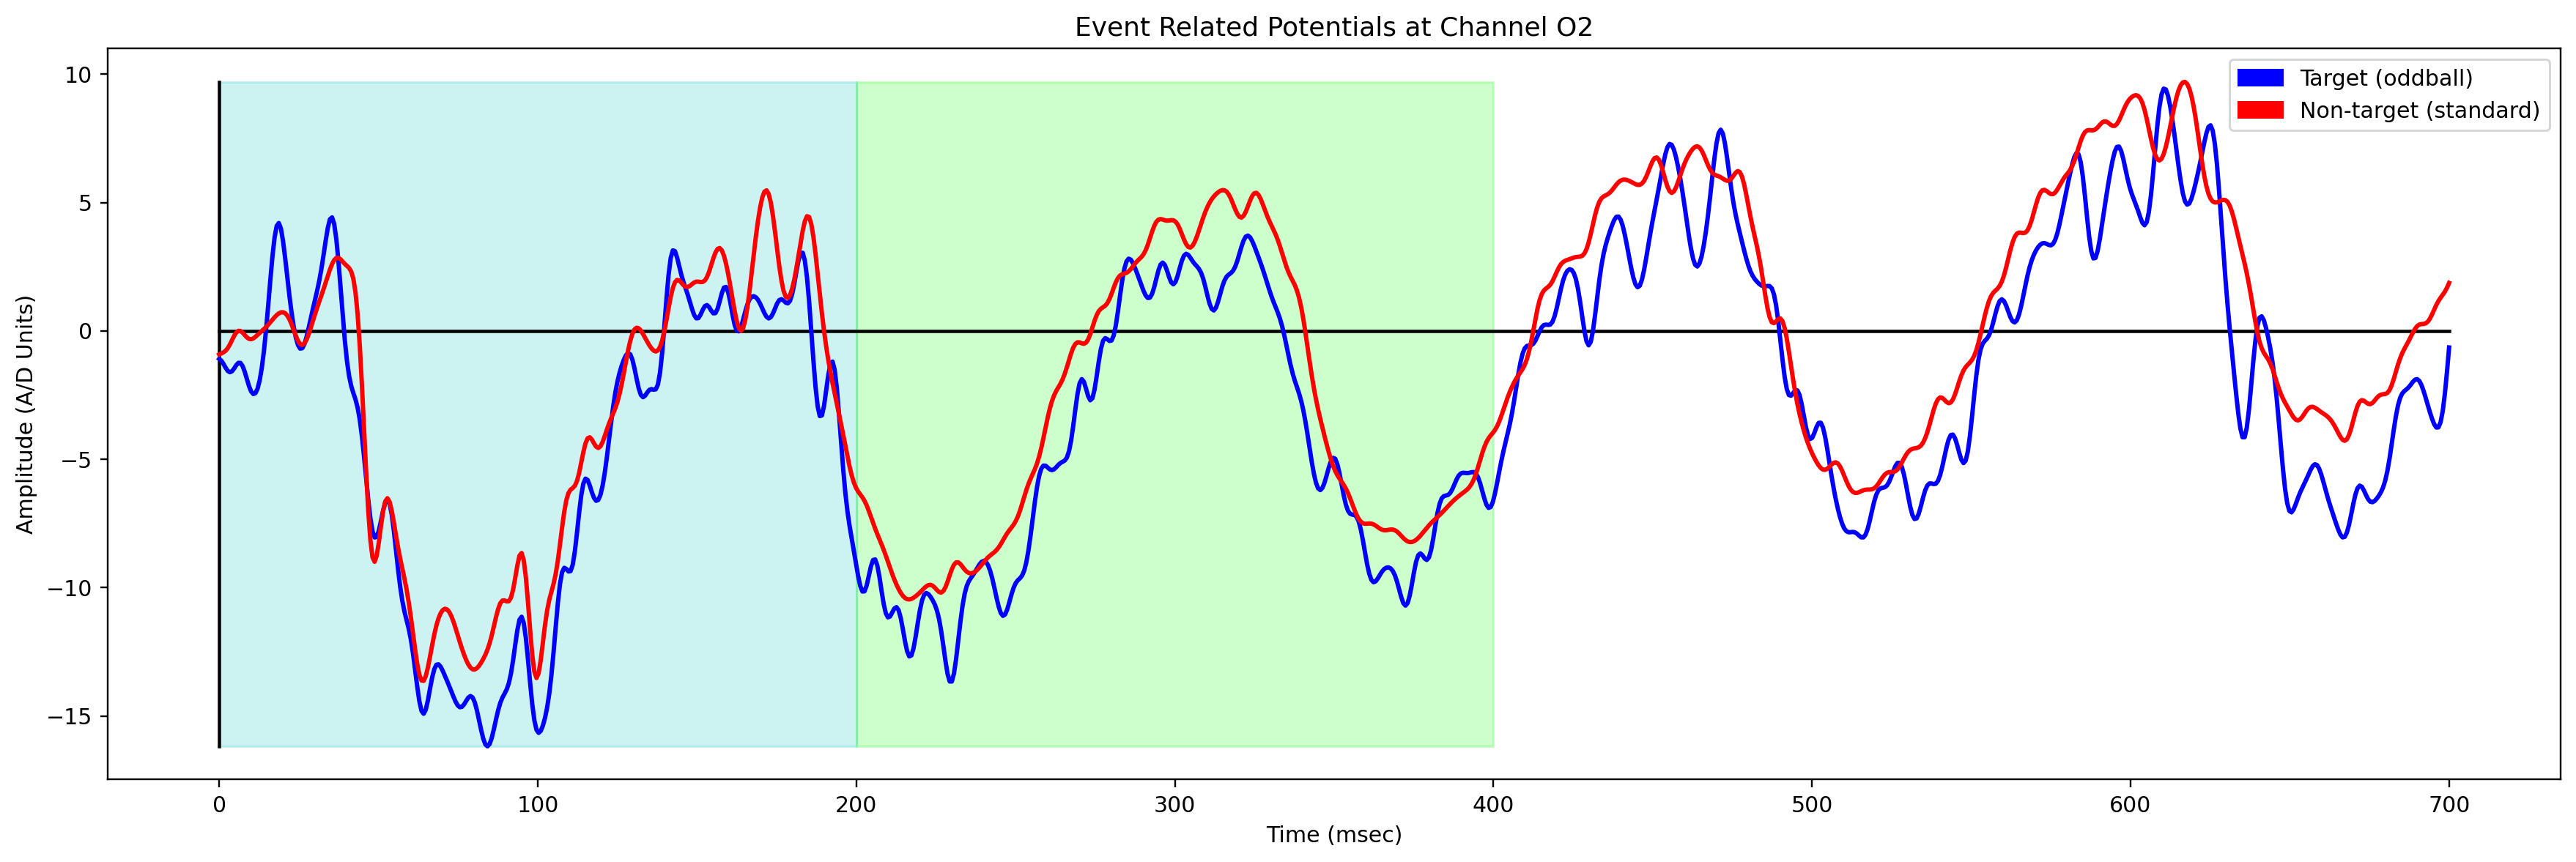

In [465]:
# Plot the graph
ch = 'O2'
ch_ind = np.where(channels == ch)[0][0]
target_avg_runs = []
nontarget_avg_runs = []

for run in range(8):
    ch_trials = eeg_runs[run][ch_ind]
    
    target_trials = []
    nontarget_trials = []
    for i, trial in enumerate(ch_trials):
        if i in target_inds:
            target_trials.append(trial)
        else:
            nontarget_trials.append(trial)
    target_trials = np.array(target_trials)
    nontarget_trials = np.array(nontarget_trials)
    ch_trials = np.array(ch_trials)

    # print(f'{target_trials.shape[0]} target trials')
    # print(f'{nontarget_trials.shape[0]} non-target trials')

    # Take the average of all trials to create an averaged ERP
    target_avg_trials = np.mean(target_trials, 0)
    nontarget_avg_trials = np.mean(nontarget_trials, 0)
    target_avg_runs.append(target_avg_trials)
    nontarget_avg_runs.append(nontarget_avg_trials)

target_avg_runs = np.array(target_avg_runs)
nontarget_avg_runs = np.array(nontarget_avg_runs)

target_avg = np.mean(target_avg_runs, 0)
nontarget_avg = np.mean(nontarget_avg_runs, 0)

times = np.linspace(epoch_start, epoch_end, ch_trials.shape[1])

# Initialize plot and calculate min and max y value
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
min_y = min(np.min(target_avg), np.min(nontarget_avg))
max_y = max(np.max(target_avg), np.max(nontarget_avg))

# Plot x and y axes
plt.plot([np.min(times), np.max(times)], [0, 0], color='k');  # x-axis
plt.plot([0, 0], [min_y, max_y], color='k');                  # y-axis

# Plot our averaged ERPs
plt.plot(times, target_avg, 'b', linewidth=2)
plt.plot(times, nontarget_avg, 'r', linewidth=2)

# Highlight the baseline window and window of interest of our ERP
baseline = patches.Rectangle([baseline_start, min_y], baseline_end, np.abs(min_y)+max_y, 
                             color='c', alpha=0.2)
erp_win = patches.Rectangle([erp_start, min_y], erp_end-erp_start, np.abs(min_y)+max_y, 
                             color='lime', alpha=0.2)

# Add our baseline and window of interest highlights
ax.add_patch(baseline)
ax.add_patch(erp_win)

# Manually create legends since patches will corrupt default handles
legend_ = [patches.Patch(color='b', label = 'Target (oddball)'),
           patches.Patch(color='r', label = 'Non-target (standard)')]

# Finalize plot and set a high DPI for a crisp, hi-res figure
plt.xlabel('Time (msec)');
plt.ylabel('Amplitude (A/D Units)');
plt.legend(handles=legend_, loc='upper right');
plt.title(f'Event Related Potentials at Channel {ch}');
fig.set_dpi(216);
plt.show();

In [466]:
# Define the window in samples
start_sample = int((erp_start + baseline_duration * 1000) / dt)
end_sample = int((erp_end + baseline_duration * 1000) / dt)

channel_scores = {}

# Iterate through each channel (excluding REF)
for i, ch_name in enumerate(channels):
    if ch_name == 'REF':
        continue
    
    targets = []
    nontargets = []
    
    # Collect trials across all runs
    for run in range(len(eeg_runs)):
        for j, trial_data in enumerate(eeg_runs[run][i]):
            is_target = all_runs_trigger[run][j]
            p300_window = trial_data[start_sample:end_sample] # Extract the P300 window (200-400ms)
            
            if is_target in all_inds[run]:
                targets.append(np.mean(p300_window))
            else:
                nontargets.append(np.mean(p300_window))
    
    # Calculate the score (delta)
    mean_target = np.mean(targets)
    mean_nontarget = np.mean(nontargets)
    score = mean_target - mean_nontarget
    
    channel_scores[ch_name] = score
    print(f"Channel {ch_name} | Target: {mean_target:.2f} | Nontarget: {mean_nontarget:.2f} | Score: {score:.2f}")

# Find the best channel
best_channel = max(channel_scores, key=channel_scores.get)
print(f"\nBest Channel from Data: {best_channel}")

Channel O1 | Target: -12.86 | Nontarget: -10.75 | Score: -2.11
Channel O2 | Target: -12.69 | Nontarget: -11.70 | Score: -0.99
Channel T5 | Target: -1.88 | Nontarget: -8.35 | Score: 6.47
Channel P3 | Target: -1.97 | Nontarget: -5.21 | Score: 3.23
Channel Pz | Target: -0.70 | Nontarget: -1.66 | Score: 0.96
Channel P4 | Target: -3.45 | Nontarget: -5.56 | Score: 2.11
Channel T6 | Target: -26.31 | Nontarget: -10.33 | Score: -15.98

Best Channel from Data: T5
